In [1]:
import pandas as pd
import numpy as np

# load dataset
df = pd.read_csv("Obesity prediction.csv")

df.head()


,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [2]:
# dataset shape
print("Shape:", df.shape)

# data types
print("\nData types:\n", df.dtypes)

# missing values
print("\nMissing values:\n", df.isnull().sum())

# duplicate rows
print("\nDuplicates:", df.duplicated().sum())


Shape: (2111, 17)

Data types:
 Gender             object
Age               float64
Height            float64
Weight            float64
family_history     object
FAVC               object
FCVC              float64
NCP               float64
CAEC               object
SMOKE              object
CH2O              float64
SCC                object
FAF               float64
TUE               float64
CALC               object
MTRANS             object
Obesity            object
dtype: object

Missing values:
 Gender            0
Age               0
Height            0
Weight            0
family_history    0
FAVC              0
FCVC              0
NCP               0
CAEC              0
SMOKE             0
CH2O              0
SCC               0
FAF               0
TUE               0
CALC              0
MTRANS            0
Obesity           0
dtype: int64

Duplicates: 24


In [3]:
# remove extra spaces and make lowercase
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(" ", "_")
df.columns = df.columns.str.lower()

df.columns


Index(['gender', 'age', 'height', 'weight', 'family_history', 'favc', 'fcvc',
       'ncp', 'caec', 'smoke', 'ch2o', 'scc', 'faf', 'tue', 'calc', 'mtrans',
       'obesity'],
      dtype='object')

In [5]:
# check number of duplicate rows
print("Duplicate rows before removal:", df.duplicated().sum())

# remove duplicates
df = df.drop_duplicates()

# confirm removal
print("Duplicate rows after removal:", df.duplicated().sum())
print("New dataset shape:", df.shape)


Duplicate rows before removal: 24
Duplicate rows after removal: 0
New dataset shape: (2087, 17)


In [6]:
# separate numerical and categorical columns
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

# fill numeric nulls with median
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# fill categorical nulls with mode
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df.isnull().sum()


,0
gender,0
age,0
height,0
weight,0
family_history,0
favc,0
fcvc,0
ncp,0
caec,0
smoke,0


In [17]:
# dictionary mapping
class_map = {
    "Insufficient_Weight": 0,
    "Normal_Weight": 0,
    "Overweight_Level_I": 0,
    "Overweight_Level_II": 0,
    "Obesity_Type_I": 1,
    "Obesity_Type_II": 1,
    "Obesity_Type_III": 1
}

# create binary target
df["obesity_binary"] = df["obesity"].map(class_map)

# check conversion
print(df[["obesity", "obesity_binary"]])


                  obesity  obesity_binary
0           Normal_Weight               0
1           Normal_Weight               0
2           Normal_Weight               0
3      Overweight_Level_I               0
4     Overweight_Level_II               0
...                   ...             ...
2106     Obesity_Type_III               1
2107     Obesity_Type_III               1
2108     Obesity_Type_III               1
2109     Obesity_Type_III               1
2110     Obesity_Type_III               1

[2087 rows x 2 columns]


In [18]:
df = df.drop(columns=["obesity"])


In [7]:
# summary statistics for numerical columns
print("Numerical summary statistics:\n")
display(df.describe())


Numerical summary statistics:



,age,height,weight,fcvc,ncp,ch2o,faf,tue
count,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000
mean,24.353090,1.702674,86.858730,2.421466,2.701179,2.004749,1.012812,0.663035
std,6.368801,0.093186,26.190847,0.534737,0.764614,0.608284,0.853475,0.608153
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.915937,1.630178,66.000000,2.000000,2.697467,1.590922,0.124505,0.000000
50%,22.847618,1.701584,83.101100,2.396265,3.000000,2.000000,1.000000,0.630866
75%,26.000000,1.769491,108.015907,3.000000,3.000000,2.466193,1.678102,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [19]:
print(df["obesity_binary"].value_counts())



obesity_binary
0    1115
1     972
Name: count, dtype: int64


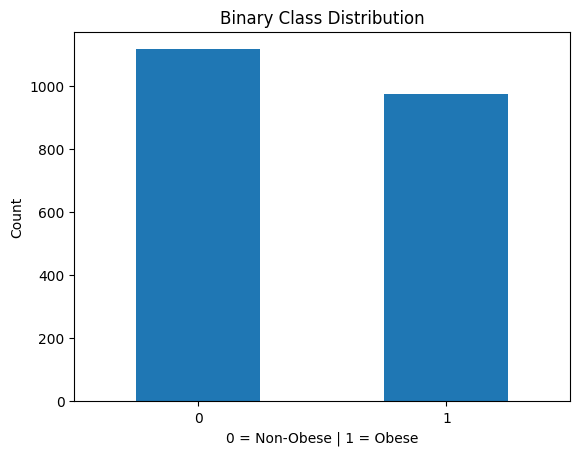

In [20]:
import matplotlib.pyplot as plt

# check class balance


plt.figure()
df["obesity_binary"].value_counts().plot(kind="bar")
plt.title("Binary Class Distribution")
plt.xlabel("0 = Non-Obese | 1 = Obese")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()


In [10]:
df.columns

Index(['gender', 'age', 'height', 'weight', 'family_history', 'favc', 'fcvc',
       'ncp', 'caec', 'smoke', 'ch2o', 'scc', 'faf', 'tue', 'calc', 'mtrans',
       'obesity'],
      dtype='object')

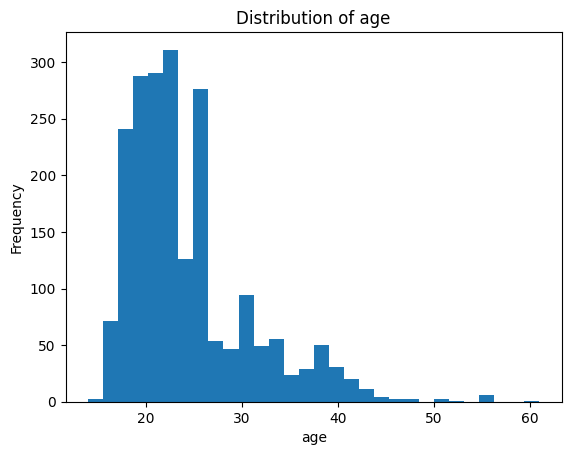

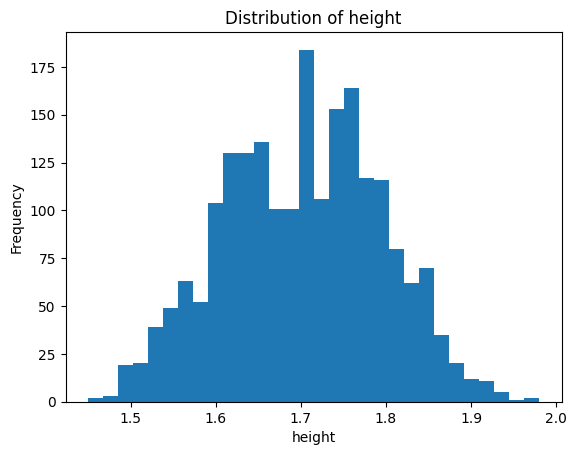

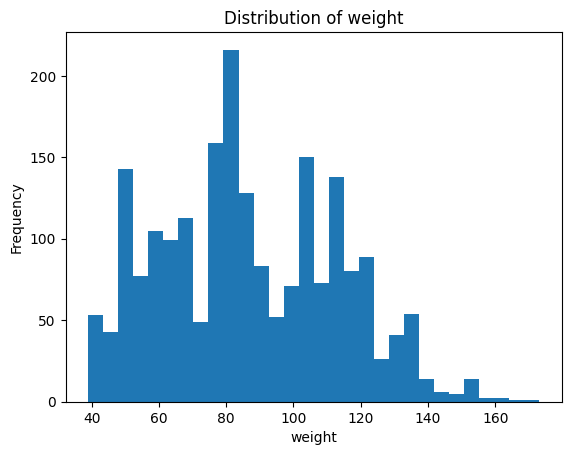

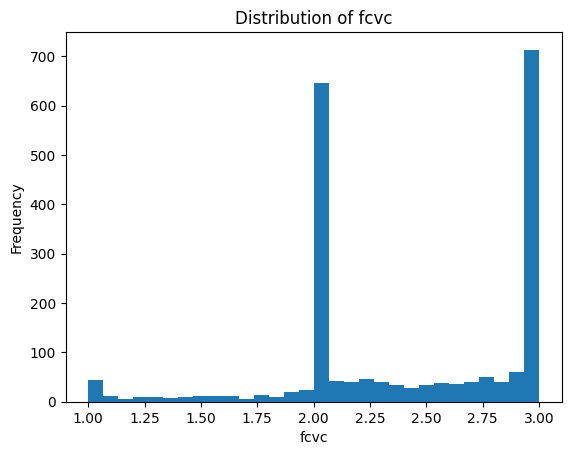

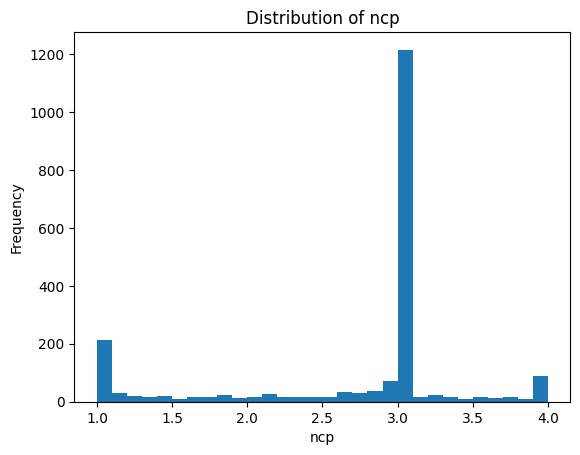

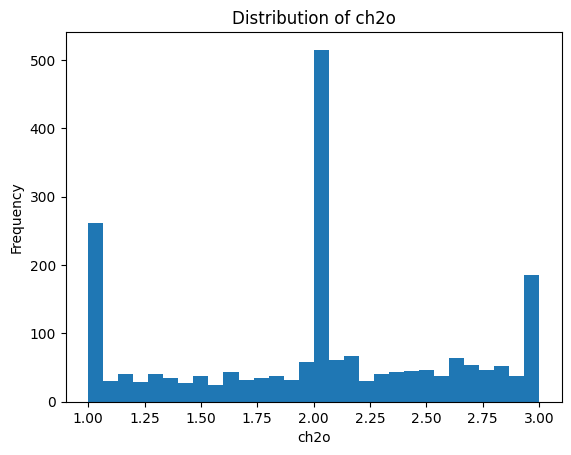

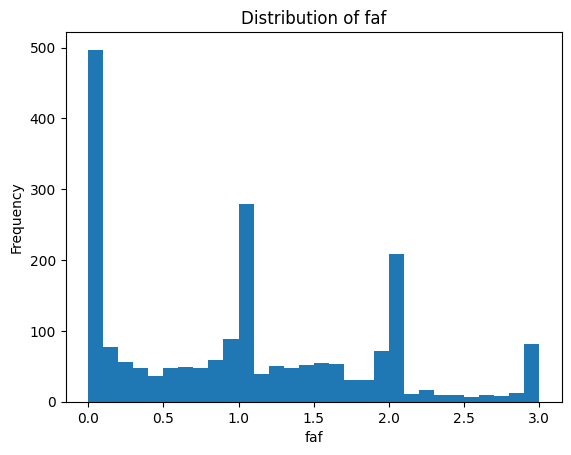

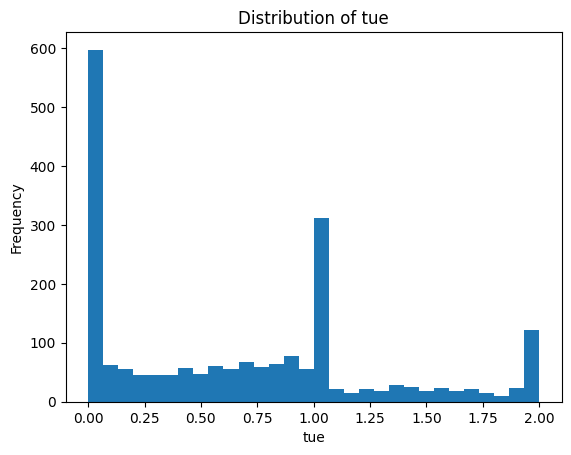

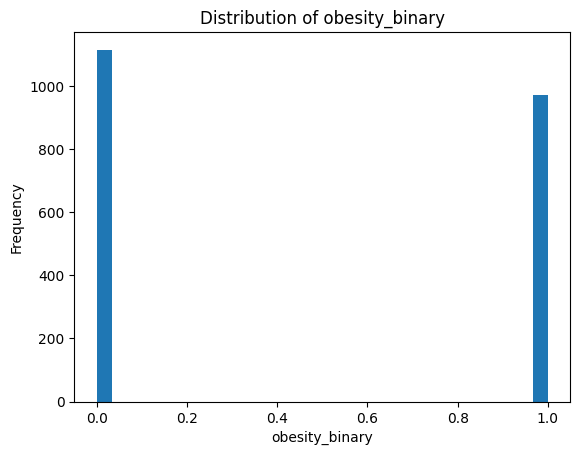

In [21]:
# find numerical columns
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    plt.figure()
    plt.hist(df[col], bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


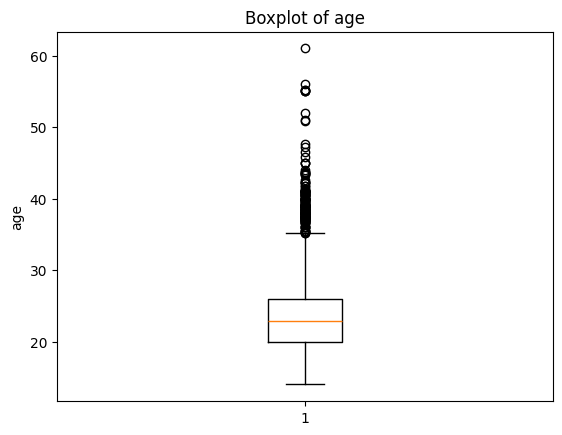

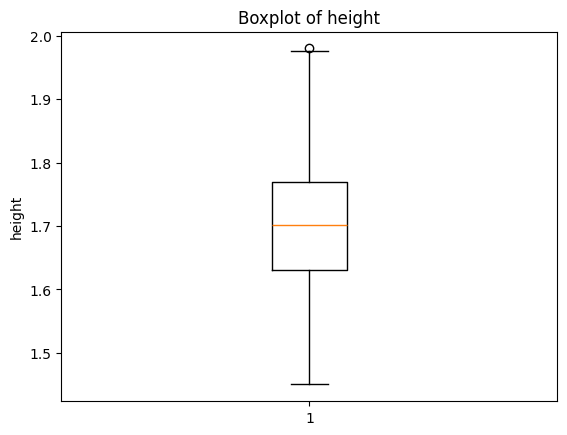

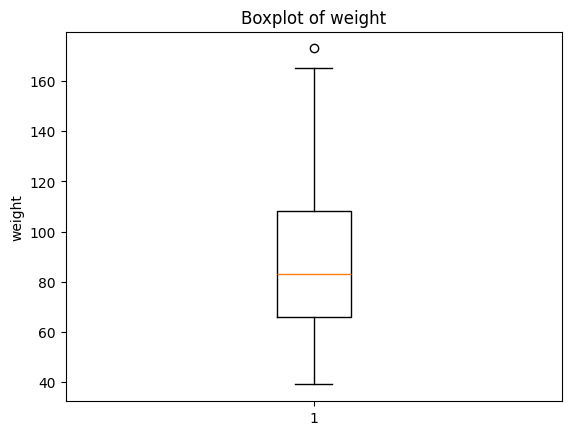

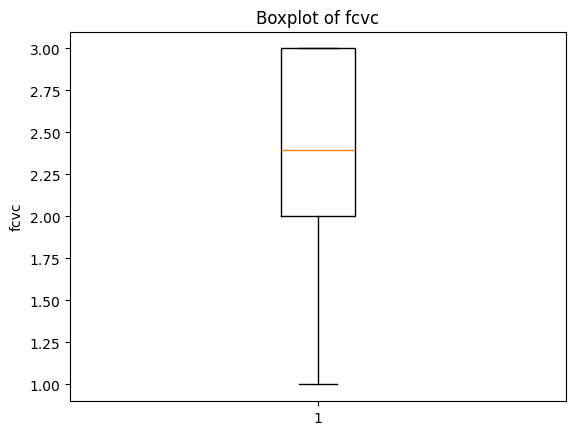

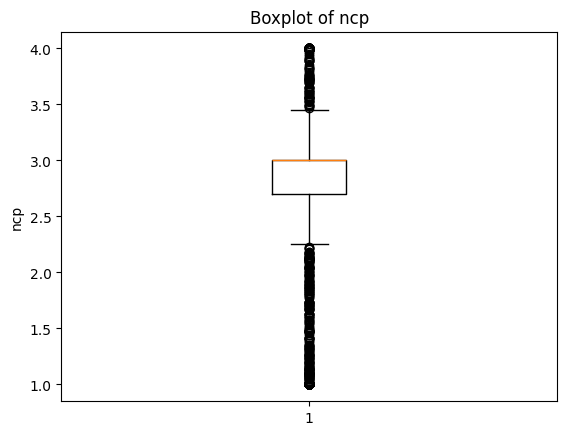

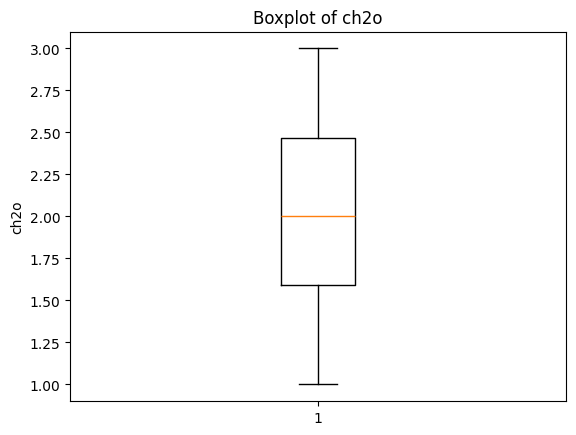

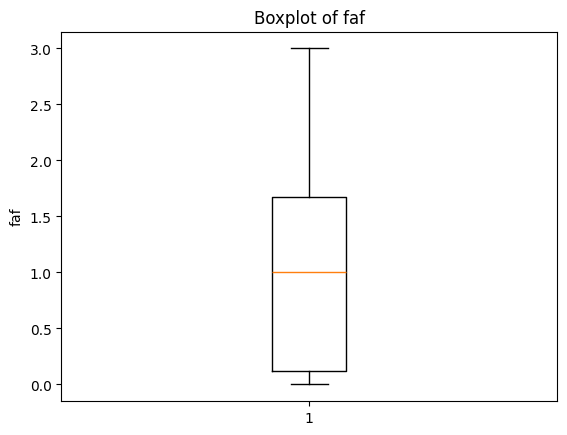

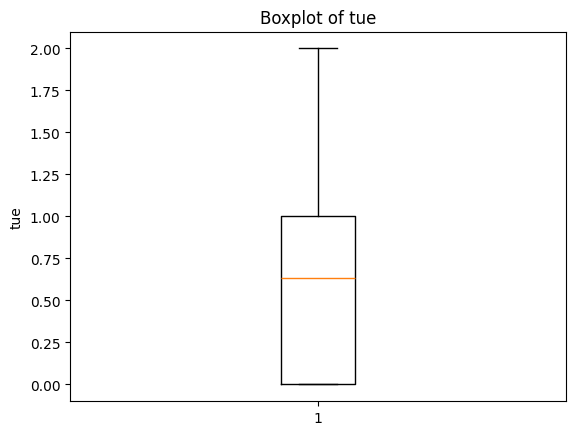

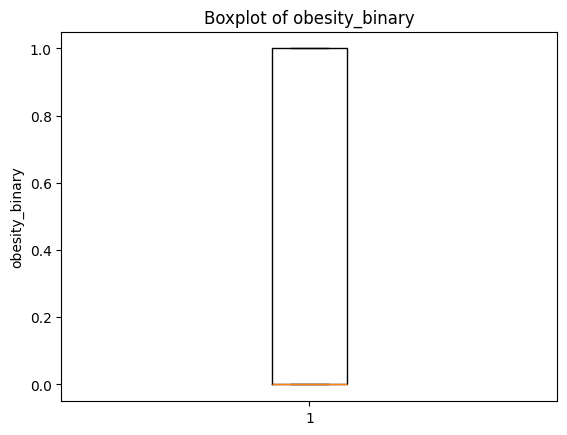

In [22]:
for col in num_cols:
    plt.figure()
    plt.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()


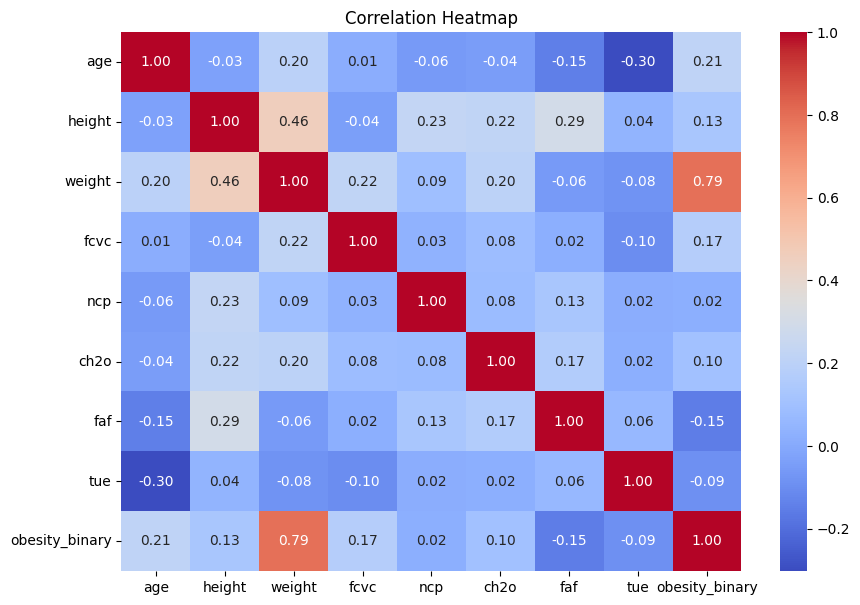

In [23]:
import seaborn as sns

corr = df[num_cols].corr()

plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()
